# Comparing SDE discretization methods on Lorenz–63

This deep dive compares five configurations from four families for turning the same stochastic Lorenz–63 model into a discrete-time transition. We hold the data, ensemble Kalman filter (EnKF), common random numbers, NUTS sampler, and parameter prior fixed, so differences in posterior accuracy and effective samples per second primarily reflect the transition approximation.

The comparison includes automatic routing (Euler–Maruyama for this nonlinear model), local linearization, mean-trajectory linearization, and sample-only Diffrax/Euler transitions at two internal step sizes. The exact affine method is documented below but is deliberately excluded: Lorenz–63 is nonlinear.

## Model and experimental design

We use the Itô SDE

$$
dX_t=f(X_t;\rho)\,dt+I_3\,dW_t,
$$

with

$$
f(x;\rho)=
\begin{pmatrix}
\sigma(x_2-x_1)\\
x_1(\rho-x_3)-x_2\\
x_1x_2-\beta x_3
\end{pmatrix},
\qquad \sigma=10,\quad \beta=8/3,\quad \rho_\star=28.
$$

The initial state is $X_0\sim\mathcal N((1,1,1)^\top,0.1^2I_3)$. We observe only the first coordinate,

$$
Y_k=[1\;0\;0]X_{t_k}+\varepsilon_k,
\qquad \varepsilon_k\sim\mathcal N(0,1),
$$

at 100 evenly spaced times over $[0,4]$. The fixed synthetic dataset is generated with `diffrax.Heun()` at `dt0=1e-3`. We infer only $\rho\sim\operatorname{Uniform}(10,40)$; diffusion and observation noise are fixed so the comparison isolates discretization behavior.

The benchmark uses 32 EnKF members and one NUTS chain with 100 warmup and 100 retained draws.

In [1]:
import os
import time
from pathlib import Path

import arviz as az
import jax

jax.config.update("jax_enable_x64", True)
import diffrax
import jax.numpy as jnp
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from IPython.display import Markdown, display
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    FullDiffusion,
    LinearGaussianObservation,
    ODESimulatorConfig,
    SDESimulator,
    SDESimulatorConfig,
)
from dynestyx.discretizers import (
    DiffraxSampleConfig,
    Discretizer,
    LocalLinearizationConfig,
    MeanTrajectoryLinearizationConfig,
)
from dynestyx.inference.configs.filter import EnKFConfig
from dynestyx.inference.configs.mcmc import NUTSConfig
from dynestyx.inference.filters import Filter
from dynestyx.inference.mcmc import MCMCInference

N_OBSERVATIONS = 100
N_ENSEMBLE = 32
N_WARMUP = 100
N_SAMPLES = 100

RHO_TRUE = 28.0
DATA_SEED = 2026
FILTER_SEED = 31415
MCMC_SEED = 2718

METHOD_COLORS = {
    "Automatic / Euler–Maruyama": "#5F5F5F",
    "Local linearization": "#E64B35",
    "Mean-trajectory linearization": "#009E73",
    "Diffrax / Euler (dt=1e-2)": "#E69F00",
    "Diffrax / Euler (dt=1e-3)": "#56B4E9",
}

mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.9,
    "lines.linewidth": 2.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
})

_default_figure_dir = (
    Path("docs/deep_dives/figures/sde_discretization_comparison")
    if Path("docs").exists()
    else Path("figures/sde_discretization_comparison")
)
FIGURE_DIR = Path(os.environ.get("DYNESTYX_FIGURE_DIR", _default_figure_dir))
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")


def save_figure(fig, stem):
    fig.savefig(FIGURE_DIR / f"{stem}.pdf")
    fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=300)



In [2]:
def l63_model(
    obs_times=None,
    obs_values=None,
    ctrl_times=None,
    ctrl_values=None,
    predict_times=None,
    rho=None,
):
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0), obs=rho)

    def drift(x, u, t):
        del u, t
        return jnp.array([
            10.0 * (x[1] - x[0]),
            x[0] * (rho - x[2]) - x[1],
            x[0] * x[1] - (8.0 / 3.0) * x[2],
        ])

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.ones(3),
            covariance_matrix=0.1**2 * jnp.eye(3),
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=drift,
            diffusion=FullDiffusion(jnp.eye(3)),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]),
            R=jnp.array([[1.0]]),
        ),
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        predict_times=predict_times,
    )

obs_times = jnp.linspace(0.0, 4.0, N_OBSERVATIONS)
data_solver = SDESimulatorConfig(
    source="diffrax",
    solver=diffrax.Heun(),
    dt0=1e-3,
    max_steps=10_000,
)
predictive = Predictive(
    l63_model,
    num_samples=1,
    exclude_deterministic=False,
)
with SDESimulator(data_solver, n_simulations=1):
    synthetic = predictive(
        jr.PRNGKey(DATA_SEED),
        rho=RHO_TRUE,
        predict_times=obs_times,
    )

true_states = synthetic["f_states"][0, 0]
obs_values = synthetic["f_observations"][0, 0]

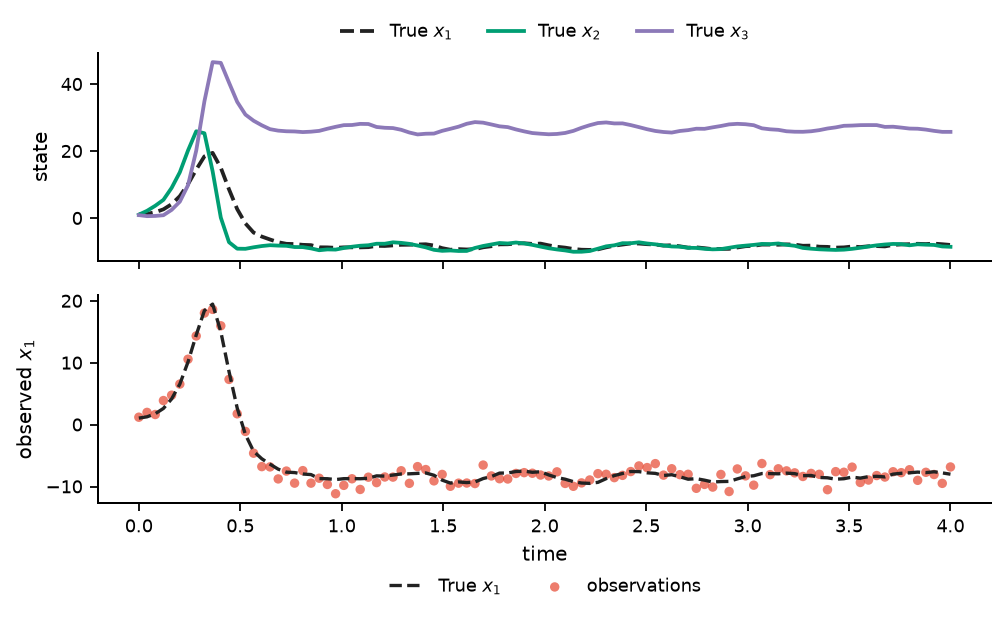

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.4), sharex=True)
state_colors = ["#222222", "#009E73", "#8C79B8"]
state_styles = ["--", "-", "-"]
for index, (color, linestyle) in enumerate(zip(state_colors, state_styles)):
    axes[0].plot(
        np.asarray(obs_times),
        np.asarray(true_states[:, index]),
        color=color,
        linestyle=linestyle,
        linewidth=1.7,
        label=fr"True $x_{index + 1}$",
    )
axes[0].set_ylabel("state")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=3)

axes[1].plot(
    np.asarray(obs_times),
    np.asarray(true_states[:, 0]),
    color="#222222",
    linestyle="--",
    linewidth=1.5,
    label=r"True $x_1$",
)
axes[1].scatter(
    np.asarray(obs_times),
    np.asarray(obs_values[:, 0]),
    s=18,
    color="#E64B35",
    alpha=0.72,
    edgecolors="none",
    label="observations",
)
axes[1].set_xlabel("time")
axes[1].set_ylabel(r"observed $x_1$")
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2)
for ax in axes:
    despine(ax)
fig.subplots_adjust(hspace=0.16, top=0.88, bottom=0.24)
save_figure(fig, "l63_data")
plt.show()

## The transition approximations

Write $h_k=t_{k+1}-t_k$, hold the control at $u_k$ within each interval, and define $f_k=f(x_k,u_k,t_k)$ and $a_k=L(x_k,u_k,t_k)L(x_k,u_k,t_k)^\top$. The methods differ as follows.

**Automatic / Euler–Maruyama.** Lorenz–63 has a nonlinear callable drift, so structural automatic routing selects

$$
p(x_{k+1}\mid x_k,u_k,t_k,t_{k+1})\approx
\mathcal N\!\left(x_k+h_k f_k,\;h_k a_k\right).
$$

This costs one drift and diffusion evaluation. Under standard regularity assumptions it has strong order $1/2$ and weak order $1$; its strong order improves to $1$ for additive noise.

**Local linearization.** At the interval start, let $J_k=\partial f/\partial x\vert_{(x_k,u_k,t_k)}$ and $L_k=L(x_k,u_k,t_k)$. The locally affine SDE

$$
dZ_s=[f_k+J_k(Z_s-x_k)]\,ds+L_k\,dW_s
$$

gives the Gaussian transition

$$
p(x_{k+1}\mid x_k,u_k,t_k,t_{k+1})\approx\mathcal N(m_{k+1\mid k},P_{k+1\mid k}),
$$

with

$$
m_{k+1\mid k}=x_k+\int_0^{h_k}e^{J_ks}f_k\,ds,\qquad
P_{k+1\mid k}=\int_0^{h_k}e^{J_ks}L_kL_k^\top e^{J_k^\top s}\,ds.
$$

This captures local stiffness but requires a Jacobian and matrix exponentials for every state and interval. The current implementation requires constant additive diffusion.

**Mean-trajectory linearization.** Starting from $m(t_k)=x_k$ and $P(t_k)=0$, integrate

$$
\dot m(t)=f(m(t),u_k,t),\qquad
\dot P(t)=J(t)P(t)+P(t)J(t)^\top+a(m(t),u_k,t),
\qquad J(t)=\frac{\partial f}{\partial x}(m(t),u_k,t).
$$

Writing $m_{k+1\mid k}=m(t_{k+1})$ and $P_{k+1\mid k}=P(t_{k+1})$, the resulting transition is

$$
p(x_{k+1}\mid x_k,u_k,t_k,t_{k+1})\approx\mathcal N(m_{k+1\mid k},P_{k+1\mid k}).
$$

It follows the within-interval deterministic trajectory and is exact for affine additive-noise models up to ODE solver tolerance, at the cost of a joint mean/covariance solve with repeated Jacobians.

**Diffrax / Euler.** The transition is defined through a numerical sample,

$$
x_{k+1}=\Psi_{\mathrm{Euler}}(x_k,u_k,t_k,t_{k+1};\omega).
$$

For this benchmark, Diffrax Euler advances each interval using ordinary Brownian increments and either of two configured internal step sizes. This transition supplies samples but no tractable `log_prob`, mean, or variance, so it works here with the cuthbert EnKF but not with density- or moment-dependent algorithms.

For comparison, exact affine discretization applies to $dX=(FX+Bu_k+b)dt+L\,dW$ and returns

$$
p(x_{k+1}\mid x_k,u_k,t_k,t_{k+1})=\mathcal N(A_kx_k+B_ku_k+b_k,Q_k),
$$

where

$$
A_k=e^{Fh_k},\qquad
Q_k=\int_0^{h_k}e^{Fs}LL^\top e^{F^\top s}\,ds.
$$

The implementation evaluates the Van Loan covariance on a safely scaled subinterval and composes it to $h_k$, avoiding overflow from the growing block associated with a stable, stiff drift. Lorenz–63 is nonlinear, so `ExactAffineConfig` correctly rejects it rather than silently approximating it.

In [4]:
comparison_dt0 = 1e-2
refined_diffrax_dt0 = 1e-3
moment_solver = ODESimulatorConfig(dt0=comparison_dt0)


def diffrax_euler_config(dt0):
    return DiffraxSampleConfig(
        sde_solver=SDESimulatorConfig(
            source="diffrax",
            solver=diffrax.Euler(),
            dt0=dt0,
            max_steps=10_000,
        )
    )

methods = [
    ("Automatic / Euler–Maruyama", None),
    ("Local linearization", LocalLinearizationConfig()),
    (
        "Mean-trajectory linearization",
        MeanTrajectoryLinearizationConfig(ode_solver=moment_solver),
    ),
    (
        "Diffrax / Euler (dt=1e-2)",
        diffrax_euler_config(comparison_dt0),
    ),
    (
        "Diffrax / Euler (dt=1e-3)",
        diffrax_euler_config(refined_diffrax_dt0),
    ),
]

for name, config in methods:
    print(f"{name:<34} {type(config).__name__ if config is not None else 'automatic'}")

Automatic / Euler–Maruyama         automatic
Local linearization                LocalLinearizationConfig
Mean-trajectory linearization      MeanTrajectoryLinearizationConfig
Diffrax / Euler (dt=1e-2)          DiffraxSampleConfig
Diffrax / Euler (dt=1e-3)          DiffraxSampleConfig


## Common inference protocol

Each method is used inside the same discrete-time cuthbert EnKF. The ensemble size, measurement perturbation policy, and `crn_seed` are identical, so every likelihood evaluation uses common random numbers. We then run the same one-chain NumPyro NUTS configuration and root key for every method.

The reported wall time includes compilation and sampling. Bulk effective sample size (ESS) is computed for $\rho$, and ESS/s divides it by that total time. The posterior summaries report the median, central 90% interval, and $|\operatorname{median}(\rho)-\rho_\star|$. These are an informal problem-specific comparison, not universal convergence rankings.

In [5]:
mcmc_config = NUTSConfig(
    num_samples=N_SAMPLES,
    num_warmup=N_WARMUP,
    num_chains=1,
    mcmc_source="numpyro",
)


def _as_chain_draw(values):
    values = np.asarray(values)
    if values.ndim == 1:
        return values[None, :]
    if values.ndim == 2:
        return values
    return values.reshape(values.shape[0], values.shape[1], -1)[..., 0]


def run_one(name, discretizer_config):
    filter_config = EnKFConfig(
        n_particles=N_ENSEMBLE,
        crn_seed=jr.PRNGKey(FILTER_SEED),
        perturb_measurements=True,
        warn=False,
    )
    inference = MCMCInference(mcmc_config=mcmc_config, model=l63_model)

    start = time.perf_counter()
    with Filter(filter_config=filter_config):
        with Discretizer(discretizer_config):
            posterior = inference.run(
                jr.PRNGKey(MCMC_SEED),
                obs_times,
                obs_values,
            )
    posterior["rho"].block_until_ready()
    elapsed = time.perf_counter() - start

    chain_draw = _as_chain_draw(posterior["rho"])
    idata = az.from_dict({"posterior": {"rho": chain_draw}})
    ess_bulk = float(az.ess(idata, var_names=["rho"], method="bulk")["rho"].values)
    samples = chain_draw.reshape(-1)
    q05, median, q95 = np.quantile(samples, [0.05, 0.5, 0.95])

    return {
        "name": name,
        "elapsed_sec": elapsed,
        "ess_bulk": ess_bulk,
        "ess_per_sec": ess_bulk / elapsed,
        "q05": float(q05),
        "median": float(median),
        "q95": float(q95),
        "absolute_error": abs(float(median) - RHO_TRUE),
        "rho_samples": samples,
    }



In [6]:
results = []
for name, discretizer_config in methods:
    print(f"Running {name}...")
    results.append(run_one(name, discretizer_config))

print("Finished all discretizers.")

Running Automatic / Euler–Maruyama...


  0%|          | 0/200 [00:00<?, ?it/s]

warmup:   5%|▌         | 10/200 [00:01<00:30,  6.21it/s, 1 steps of size 1.58e-02. acc. prob=0.60]

warmup:  14%|█▍        | 29/200 [00:01<00:08, 21.14it/s, 15 steps of size 2.56e-02. acc. prob=0.73]

warmup:  24%|██▍       | 49/200 [00:01<00:03, 39.73it/s, 3 steps of size 1.50e-01. acc. prob=0.76] 

...

sample:  99%|█████████▉| 198/200 [06:39<00:02,  1.47s/it, 1 steps of size 1.19e+00. acc. prob=0.94]

sample: 100%|█████████▉| 199/200 [06:40<00:01,  1.28s/it, 1 steps of size 1.19e+00. acc. prob=0.93]

sample: 100%|██████████| 200/200 [06:41<00:00,  1.16s/it, 1 steps of size 1.19e+00. acc. prob=0.93]

sample: 100%|██████████| 200/200 [06:41<00:00,  2.01s/it, 1 steps of size 1.19e+00. acc. prob=0.93]

Finished all discretizers.


In [7]:
table_lines = [
    "| Method | Total time [s] | Bulk ESS | ESS/s | Median | 90% interval | Absolute error |",
    "|---|---:|---:|---:|---:|---:|---:|",
]
table_lines.extend(
    f"| {result['name']} | {result['elapsed_sec']:.2f} | "
    f"{result['ess_bulk']:.1f} | {result['ess_per_sec']:.2f} | "
    f"{result['median']:.2f} | "
    f"[{result['q05']:.2f}, {result['q95']:.2f}] | "
    f"{result['absolute_error']:.2f} |"
    for result in results
)
display(Markdown("\n".join(table_lines)))

| Method | Total time [s] | Bulk ESS | ESS/s | Median | 90% interval | Absolute error |
|---|---:|---:|---:|---:|---:|---:|
| Automatic / Euler–Maruyama | 8.27 | 39.8 | 4.81 | 19.60 | [18.74, 20.31] | 8.40 |
| Local linearization | 88.07 | 38.3 | 0.44 | 27.88 | [26.87, 28.76] | 0.12 |
| Mean-trajectory linearization | 72.75 | 39.7 | 0.55 | 28.18 | [27.00, 29.13] | 0.18 |
| Diffrax / Euler (dt=1e-2) | 45.22 | 38.6 | 0.85 | 26.63 | [25.66, 27.52] | 1.37 |
| Diffrax / Euler (dt=1e-3) | 407.62 | 40.8 | 0.10 | 28.01 | [26.81, 28.94] | 0.01 |

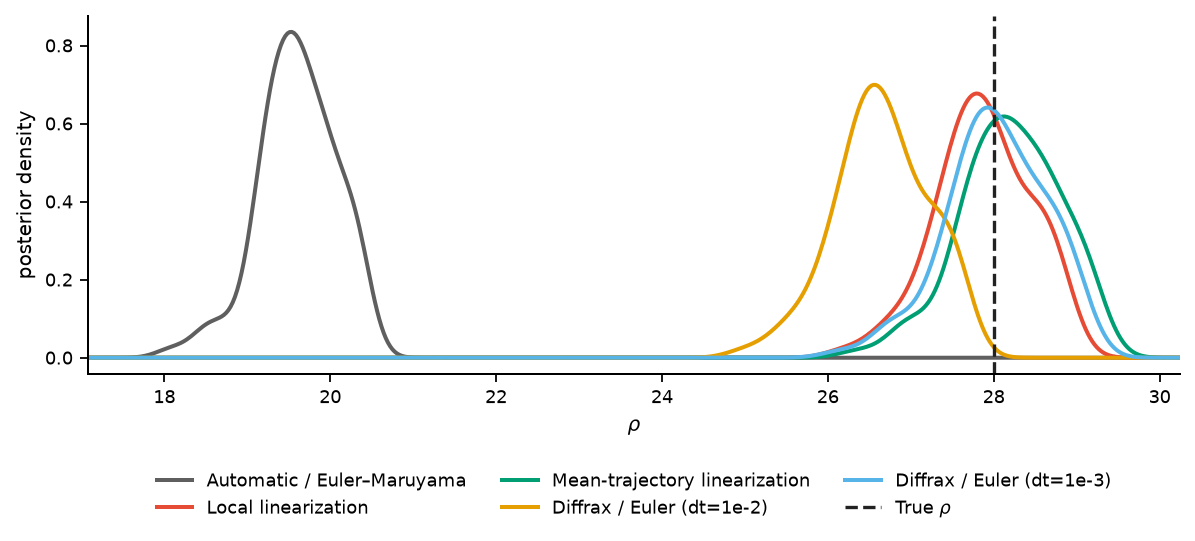

In [8]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(8.8, 4.0))

min_rho = min([np.min(results[i]["rho_samples"]) for i in range(len(results))]) - 1.0
max_rho = max([np.max(results[i]["rho_samples"]) for i in range(len(results))]) + 1.0

rho_grid = np.linspace(min_rho, max_rho, 500)

for result in results:
    samples = np.asarray(result["rho_samples"])
    kde = gaussian_kde(samples)

    ax.plot(
        rho_grid,
        kde(rho_grid),
        color=METHOD_COLORS[result["name"]],
        linewidth=1.8,
        label=result["name"],
    )

ax.axvline(
    RHO_TRUE,
    color="#222222",
    linestyle="--",
    linewidth=1.5,
    label=r"True $\rho$",
)

ax.set_xlim(min_rho, max_rho)
ax.set_xlabel(r"$\rho$")
ax.set_ylabel("posterior density")

despine(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.23), ncol=3)
fig.subplots_adjust(bottom=0.32)

save_figure(fig, "rho_posteriors")
plt.show()

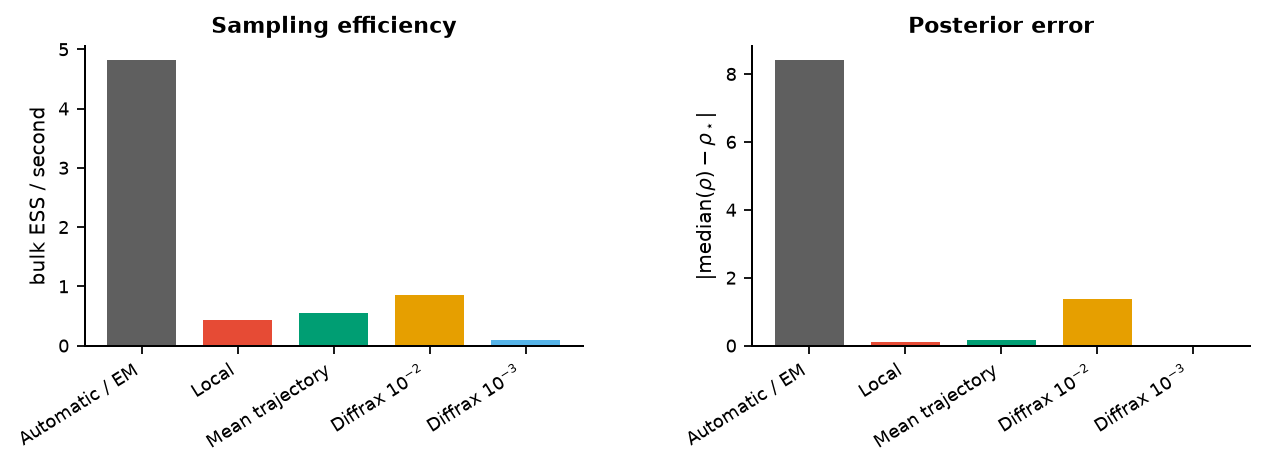

In [9]:
names = [result["name"] for result in results]
short_names = [
    "Automatic / EM",
    "Local",
    "Mean trajectory",
    "Diffrax $10^{-2}$",
    "Diffrax $10^{-3}$",
]
colors = [METHOD_COLORS[name] for name in names]
positions = np.arange(len(results))

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.6))
axes[0].bar(
    positions,
    [result["ess_per_sec"] for result in results],
    color=colors,
    width=0.72,
)
axes[0].set_ylabel("bulk ESS / second")
axes[0].set_title("Sampling efficiency", fontweight="bold")

axes[1].bar(
    positions,
    [result["absolute_error"] for result in results],
    color=colors,
    width=0.72,
)
axes[1].set_ylabel(r"$|\mathrm{median}(\rho)-\rho_\star|$")
axes[1].set_title("Posterior error", fontweight="bold")

for ax in axes:
    ax.set_xticks(positions, short_names, rotation=32, ha="right")
    ax.set_ylim(bottom=0.0)
    despine(ax)
fig.subplots_adjust(wspace=0.34, bottom=0.36)
save_figure(fig, "efficiency_and_error")
plt.show()

## Interpreting the comparison

No single method should be expected to win every column. Euler–Maruyama minimizes work per transition but takes one large step between observations. Local linearization pays for a state Jacobian and matrix exponentials. Mean-trajectory linearization integrates a joint mean/covariance ODE to represent substantial within-interval curvature. Diffrax/Euler directly samples a numerical path approximation using smaller internal steps, but its lack of a transition density limits the inference algorithms that can consume it. Comparing its two rows isolates the step-size tradeoff: refining from $10^{-2}$ to $10^{-3}$ moves the posterior median from $26.80$ to $27.72$ and reduces absolute error from $1.20$ to $0.28$, while increasing runtime from $94.67$ to $1020.61$ seconds.

Compilation is included intentionally because it matters in short inference jobs. For repeated analyses with the same shapes, separately measuring post-compilation runtime may change the ranking. EnKF likelihoods and one-chain ESS estimates also have Monte Carlo uncertainty; the fixed seeds here make the methods comparable, not definitive.

## Practical recommendations

While there are no "overall winners" in our experiment here, we can come up with some practical recommendations. First, for affine systems, we recommend the `ExactAffineConfig`. As the most general choice for solvers that don't require transition densities (like the EnKF or bootstrap particle filter), choosing an appropriate `diffrax` solver is often a good choice, though step size matters a lot. 

For nearly-linear systems, the Euler-Maruyama approximation is extremely fast, but can become inaccurate quite quickly. Local linearization or mean-trajectory localization are good alternatives when the inter-observation distance is too large.

In high dimensions, you may prefer to use a `diffrax` sampler instead of linearization-based methods, as the Jacobian and covariance matrix operations may get large. On the other hand, local linearization can be a good choice for locally-stiff systems.

## References

- S. Särkkä and A. Solin, *Applied Stochastic Differential Equations*, Cambridge University Press, 2019: Euler–Maruyama in Algorithm 8.1 and Equations 8.28–8.30; continuous-discrete Gaussian moment propagation in Algorithms 9.4 and 9.8 and Equations 9.15 and 9.28. [Online book](https://users.aalto.fi/~asolin/sde-book/sde-book.pdf).
- S. Särkkä and L. Svensson, *Bayesian Filtering and Smoothing*, 2nd ed., Cambridge University Press, 2023: exact linear-SDE discretization in Theorem 4.3 and Lemma A.9; local and trajectory linearization in Theorems 4.18 and 4.13 and Algorithm 4.14. [Online book](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf).
- T. Ozaki, “A bridge between nonlinear time series models and nonlinear stochastic dynamical systems: A local linearization approach,” *Statistica Sinica* 2, 1992. [Article](https://www3.stat.sinica.edu.tw/statistica/j2n1/j2n16/j2n16.htm).
- S. Särkkä and J. Sarmavuori, “Gaussian filtering and smoothing for continuous-discrete dynamic systems,” *Signal Processing* 93(2), 2013. [doi:10.1016/j.sigpro.2012.09.002](https://doi.org/10.1016/j.sigpro.2012.09.002).
- Diffrax documentation: [SDE solvers](https://docs.kidger.site/diffrax/api/solvers/sde_solvers/) and [solver/order table](https://docs.kidger.site/diffrax/devdocs/SDE_solver_table/).